# Library and Import

In [ ]:
import pandas as pd
import numpy as np
np.random.seed(77)
import more_itertools
import os
import io
import re
import requests
import PIL
import itertools
import random
import seaborn as sns
import urllib.request
import urllib.error
import h5py

import matplotlib.pyplot as plt
import matplotlib.font_manager
import matplotlib.colors as mcolors
from matplotlib.colors import to_hex

!pip install umap-learn
import umap
import matplotlib.pyplot as plt
import plotly.express as px

!pip install rdkit-pypi
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
!pip install rdkit-pypi py3Dmol
import py3Dmol
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem.rdMolDescriptors import GetMACCSKeysFingerprint
from rdkit.Chem.AtomPairs import Pairs

import torch
!pip install torch-geometric
from torch_geometric.datasets import MoleculeNet

from rdkit.Chem import AllChem, DataStructs

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 52.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.8 MB/s eta 0:00:00


In [ ]:
!pip install torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import DataLoader
from torch_geometric.datasets import MoleculeNet
from torch_geometric.nn import GINConv, GINEConv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp311-cp311-linux_x86_64.whl size=545106 sha256=eab9e2fabc2a54da60a35a36837e1dcbb2775a6c82a71fa32ff8d6fa267953ea
  Stored in directory: /root/.cache/pip/wheels/b8/d4/0e/a80af2465354ea7355a2c153b11af2da739cfcf08b6c0b28e2
  Created wheel for torch-sparse: filename=torch_sparse-0.6.18-cp311-cp311-linux_x86_64.whl size=1122943 sha256=86b32a30236756d3c36d618cd514126c7803f77763dc4ca4203fb80f41c5479f
  Stored in directory: /root/.cache/pip/wheels/75/e2/1e/299c596063839303657c211f587f05591891cc6cf126d94d21
  Created wheel for torc

#Exercise 1

## Molecular Databases Summary  

Molecular databases store and organize chemical information, making it easier to study molecules in different contexts.  

- **Biological databases** (e.g., Rhea, KEGG, ChEBI) focus on metabolites, cofactors, and biochemical reactions.  
- **Drug discovery databases** (e.g., PubChem, ChEMBL, DrugBank) contain bioactive molecules, including drugs and their interactions with proteins.  
- **Materials science databases** (e.g., Materials Project, AFLOW) store data on synthetic and inorganic compounds.  

### **Exploring Rhea**  
Rhea is a curated database of biochemical reactions, useful for studying metabolism and enzyme-catalyzed processes.  
- Provides molecular representations like SMILES and InChI.  

### **Key Takeaways**  
- Biological and drug-related databases have different focuses—one on metabolism, the other on pharmacology.  
- Rhea helps visualize molecular interactions and pathways.  
- These databases are essential for understanding biochemical processes and applying machine learning in chemistry.  


# Exercise 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/chem_169/Act_3/"
Rhea_file = f"{file_path}/rhea_steroid_smiles.txt"

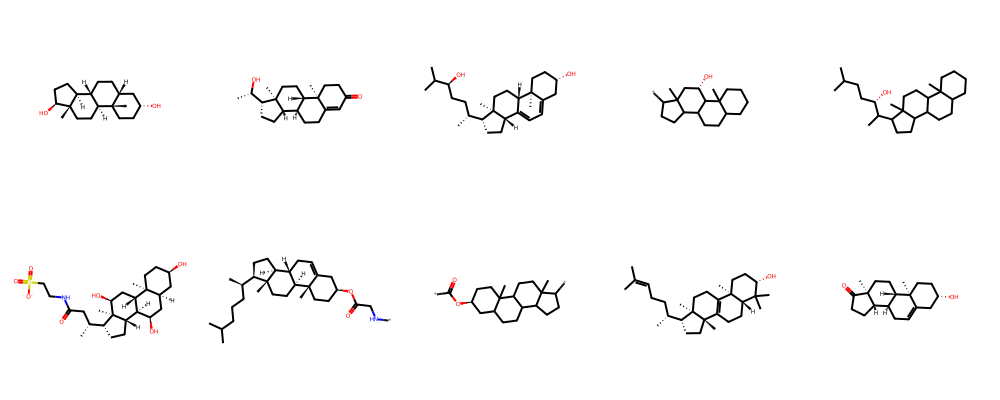

In [ ]:
#@title 2D
with open(Rhea_file, "r") as f:
    lines = f.readlines()

data = []
for line in lines:
    parts = line.strip().split("  ")  # Handle double spaces
    if len(parts) == 2:
        compound_id, smiles = parts
        compound_id = compound_id.replace("Compound ", "").strip()
        data.append((compound_id, smiles))

# Convert to DataFrame
df = pd.DataFrame(data, columns=["Compound_ID", "SMILES"])

# Convert SMILES to RDKit molecule objects
df["Molecule"] = df["SMILES"].apply(lambda x: Chem.MolFromSmiles(x) if x else None)

# Display some molecular structures
img = Draw.MolsToGridImage(df["Molecule"][:10], molsPerRow=5, subImgSize=(200, 200))
img

# Exercise 3

In [ ]:
#@title RDKit Fingerprints
df["RDKitFP"] = df["Molecule"].apply(lambda mol: AllChem.RDKFingerprint(mol, fpSize =1024) if mol else None)
# Display first few rows with fingerprints
df.head()

,Compound_ID,SMILES,Molecule,RDKitFP
0,1,[H][C@]12CC[C@]3([H])[C@]([H])(CC[C@]4(C)[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x7fb6518974c0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
1,2,[H][C@@]12CCC3=CC(=O)CC[C@]3(C)[C@@]1([H])CC[C...,<rdkit.Chem.rdchem.Mol object at 0x7fb6518973e0>,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, ..."
2,3,[H][C@@]12CC[C@]([H])([C@H](C)CC[C@H](O)C(C)C)...,<rdkit.Chem.rdchem.Mol object at 0x7fb651897530>,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, ..."
3,4,*C1CCC2C3CCC4CCCCC4(C)C3[C@@H](O)CC12C,<rdkit.Chem.rdchem.Mol object at 0x7fb6518975a0>,"[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, ..."
4,5,CC(C)CC[C@H](O)C(C)C1CCC2C3CCC4CCCCC4(C)C3CCC21C,<rdkit.Chem.rdchem.Mol object at 0x7fb651897610>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."


In [ ]:
#@title Morgan fingerprints
def get_morgan_fp(mol, radius=2, n_bits=1024):
    return list(GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits, useFeatures=True)) if mol else None

def get_maccs_fp(mol):
    return list(GetMACCSKeysFingerprint(mol)) if mol else None

def get_atom_pair_fp(mol, n_bits=1024):
    generator = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=n_bits)
    return list(generator.GetFingerprint(mol)) if mol else None

# Generate fingerprints and store them in new columns
df["Morgan_FP"] = df["Molecule"].apply(get_morgan_fp)
df["MACCS_FP"] = df["Molecule"].apply(get_maccs_fp)
df["AtomPair_FP"] = df["Molecule"].apply(get_atom_pair_fp)

# Display the updated DataFrame
df.head()

,Compound_ID,SMILES,Molecule,RDKitFP,Morgan_FP,MACCS_FP,AtomPair_FP
0,1,[H][C@]12CC[C@]3([H])[C@]([H])(CC[C@]4(C)[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x7fb6518974c0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2,[H][C@@]12CCC3=CC(=O)CC[C@]3(C)[C@@]1([H])CC[C...,<rdkit.Chem.rdchem.Mol object at 0x7fb6518973e0>,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, ...","[1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,3,[H][C@@]12CC[C@]([H])([C@H](C)CC[C@H](O)C(C)C)...,<rdkit.Chem.rdchem.Mol object at 0x7fb651897530>,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,4,*C1CCC2C3CCC4CCCCC4(C)C3[C@@H](O)CC12C,<rdkit.Chem.rdchem.Mol object at 0x7fb6518975a0>,"[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,5,CC(C)CC[C@H](O)C(C)C1CCC2C3CCC4CCCCC4(C)C3CCC21C,<rdkit.Chem.rdchem.Mol object at 0x7fb651897610>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."


#Exercise 4

In [ ]:
# Convert fingerprints to a NumPy array
fingerprint_array = np.array(df["RDKitFP"].dropna().tolist())

# Apply UMAP for dimensionality reduction
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_2d = umap_model.fit_transform(fingerprint_array)

# Add UMAP coordinates to the DataFrame
df_umap = df.dropna(subset=["RDKitFP"]).copy()
df_umap["UMAP_1"] = umap_2d[:, 0]
df_umap["UMAP_2"] = umap_2d[:, 1]

# Display first few rows with UMAP coordinates
df_umap.head()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,Compound_ID,SMILES,Molecule,RDKitFP,Morgan_FP,MACCS_FP,AtomPair_FP,UMAP_1,UMAP_2
0,1,[H][C@]12CC[C@]3([H])[C@]([H])(CC[C@]4(C)[C@@H...,<rdkit.Chem.rdchem.Mol object at 0x7fb6518974c0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",12.676495,2.009398
1,2,[H][C@@]12CCC3=CC(=O)CC[C@]3(C)[C@@]1([H])CC[C...,<rdkit.Chem.rdchem.Mol object at 0x7fb6518973e0>,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, ...","[1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",8.756611,17.350361
2,3,[H][C@@]12CC[C@]([H])([C@H](C)CC[C@H](O)C(C)C)...,<rdkit.Chem.rdchem.Mol object at 0x7fb651897530>,"[0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, ...",4.845884,21.740454
3,4,*C1CCC2C3CCC4CCCCC4(C)C3[C@@H](O)CC12C,<rdkit.Chem.rdchem.Mol object at 0x7fb6518975a0>,"[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",8.891172,5.178689
4,5,CC(C)CC[C@H](O)C(C)C1CCC2C3CCC4CCCCC4(C)C3CCC21C,<rdkit.Chem.rdchem.Mol object at 0x7fb651897610>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",11.700188,2.473657


In [ ]:
import plotly.express as px

# Create scatter plot
fig = px.scatter(
    df_umap,
    x="UMAP_1",
    y="UMAP_2",
    hover_data=["Compound_ID", "SMILES"],  # Shows Compound ID & SMILES on hover
    title="UMAP Projection of Steroid RDKit_Fingerprints"
)

# Show plot
fig.show()

In [ ]:
#@title Morgan_FP

# Convert fingerprint lists into NumPy arrays for dimensionality reduction
X = np.array(df["Morgan_FP"].to_list())

# Apply UMAP to reduce to 2D
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="jaccard", random_state=42)
X_umap = umap_model.fit_transform(X)

# Add UMAP results to DataFrame
df["UMAP_1"] = X_umap[:, 0]
df["UMAP_2"] = X_umap[:, 1]

# Generate 2D molecule images for interactive plot
df["Molecule_Image"] = df["Molecule"].apply(lambda x: Draw.MolToImage(x, size=(150, 150)))

# Create an interactive scatter plot using Plotly
fig = px.scatter(
    df,
    x="UMAP_1",
    y="UMAP_2",
    hover_name="Compound_ID",
    hover_data={"SMILES": True},
    title="UMAP Projection of Steroid Molecule Space Morgan_FP"
)

# Show plot
fig.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1887: UserWarning:

gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



#Exercise 5_morgan

In [ ]:
#@title Load the ESOL Dataset

# Load ESOL dataset (molecular solubility dataset)
dataset = MoleculeNet(root=".", name="ESOL")

# Convert to Pandas DataFrame
esol_data = []
for d in dataset:
    smiles = d.smiles
    solubility = d.y.item()  # Target variable (solubility)
    esol_data.append([smiles, solubility])

df_solubility_Morgan = pd.DataFrame(esol_data, columns=["SMILES", "Solubility"])

# Display dataset
df_solubility_Morgan.head()

,SMILES,Solubility
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [ ]:
# Convert SMILES to RDKit molecules
df_solubility_Morgan["Molecule"] = df_solubility_Morgan["SMILES"].apply(lambda x: Chem.MolFromSmiles(x))

# Function to generate Morgan fingerprints
def get_morgan_fp(mol, radius=2, n_bits=1024):
    return list(AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)) if mol else None

# Generate fingerprints
df_solubility_Morgan["Morgan_FP"] = df_solubility_Morgan["Molecule"].apply(get_morgan_fp)

# Convert fingerprint lists to feature matrix
X = np.array(df_solubility_Morgan["Morgan_FP"].to_list())
y = np.array(df_solubility_Morgan["Solubility"])

# Check shapes
X.shape, y.shape

((1128, 1024), (1128,))

In [ ]:
# Split data into train & test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

# Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"📊 Model Performance:\nRMSE: {rmse:.3f} | R²: {r2:.3f}")

📊 Model Performance:
RMSE: 1.189 | R²: 0.701


In [ ]:
from xgboost import XGBRegressor

# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict & evaluate
y_pred_xgb = xgb_model.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"📊 XGBoost Performance:\nRMSE: {rmse_xgb:.3f} | R²: {r2_xgb:.3f}")

📊 XGBoost Performance:
RMSE: 1.166 | R²: 0.712


#Exercise 6

In [ ]:
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import MoleculeNet
from rdkit import Chem
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from torch_geometric.data import Data

In [125]:
from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
import torch

# Load ESOL dataset (molecular solubility dataset)
dataset = MoleculeNet(root=".", name="ESOL")

# Split dataset into 80% training and 20% test
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Create DataLoaders for batching
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check sample molecule
sample = dataset[0]
print("Node features shape:", sample.x.shape)
print("Edge index shape:", sample.edge_index.shape)
print("Solubility value:", sample.y.item())


Node features shape: torch.Size([32, 9])
Edge index shape: torch.Size([2, 68])
Solubility value: -0.7699999809265137


In [127]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_add_pool

class SimpleGNN(torch.nn.Module):
    def __init__(self, num_node_features):
        super(SimpleGNN, self).__init__()
        self.conv1 = GCNConv(num_node_features, 32)  # Increase hidden dimension
        self.conv2 = GCNConv(32, 32)
        self.fc = torch.nn.Linear(32, 1)  # Predict solubility

    def forward(self, data):
        x = data.x.float()  # Ensure node features are float
        edge_index = data.edge_index
        batch = data.batch if hasattr(data, 'batch') else None

        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))

        x = global_add_pool(x, batch) if batch is not None else x.mean(dim=0)  # Pooling

        return self.fc(x).squeeze(1)  # Ensure correct output shape

In [128]:
# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleGNN(num_node_features=dataset.num_node_features).to(device)

# Define loss function and optimizer
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training function
def train():
    model.train()
    total_loss = 0
    for data_batch in train_loader:
        data_batch = data_batch.to(device)
        optimizer.zero_grad()
        out = model(data_batch)
        target = data_batch.y.float()
        loss = criterion(out.view(-1), target.view(-1))  # Ensure shapes match
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

# Testing function
def test(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data_batch in loader:
            data_batch = data_batch.to(device)
            out = model(data_batch)
            target = data_batch.y.float()
            loss = criterion(out.view(-1), target.view(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

# Training loop (100 epochs)
for epoch in range(1, 501):
    loss = train()
    test_loss = test(test_loader)
    print(f"Epoch {epoch}, Train Loss: {loss:.4f}")

Epoch 1, Train Loss: 154.7214, Test Loss: 14.2090
Epoch 2, Train Loss: 6.9649, Test Loss: 2.8586
Epoch 3, Train Loss: 2.8877, Test Loss: 2.2974
Epoch 4, Train Loss: 2.5939, Test Loss: 2.1229
Epoch 5, Train Loss: 2.5578, Test Loss: 2.0470
Epoch 6, Train Loss: 2.4292, Test Loss: 1.9608
Epoch 7, Train Loss: 2.3607, Test Loss: 1.9201
Epoch 8, Train Loss: 2.3214, Test Loss: 1.9015
Epoch 9, Train Loss: 2.2810, Test Loss: 1.8974
Epoch 10, Train Loss: 2.2468, Test Loss: 1.8392
Epoch 11, Train Loss: 2.2752, Test Loss: 1.8143
Epoch 12, Train Loss: 2.2552, Test Loss: 1.7871
Epoch 13, Train Loss: 2.1362, Test Loss: 1.7262
Epoch 14, Train Loss: 2.0631, Test Loss: 1.7122
Epoch 15, Train Loss: 1.9735, Test Loss: 1.6827
Epoch 16, Train Loss: 1.9558, Test Loss: 1.5983
Epoch 17, Train Loss: 1.8768, Test Loss: 1.5580
Epoch 18, Train Loss: 1.8460, Test Loss: 1.5378
Epoch 19, Train Loss: 1.7633, Test Loss: 1.4735
Epoch 20, Train Loss: 1.7512, Test Loss: 1.4567
Epoch 21, Train Loss: 1.7044, Test Loss: 1.474

In [130]:
from sklearn.metrics import mean_squared_error, r2_score

# Modified test function to return predictions & true values
def evaluate_gnn(loader):
    model.eval()
    predictions, true_values = [], []

    with torch.no_grad():
        for data_batch in loader:
            data_batch = data_batch.to(device)
            out = model(data_batch).cpu().numpy()  # Convert output to NumPy
            target = data_batch.y.cpu().numpy()  # Convert target to NumPy

            predictions.extend(out.flatten())  # Store predictions
            true_values.extend(target.flatten())  # Store actual values

    # Compute RMSE and R²
    rmse = mean_squared_error(true_values, predictions)
    r2 = r2_score(true_values, predictions)

    return rmse, r2

# Compute RMSE and R² for GNN
gnn_rmse, gnn_r2 = evaluate_gnn(test_loader)
print(f"GNN RMSE: {gnn_rmse:.4f}, GNN R²: {gnn_r2:.4f}")

GNN RMSE: 1.0443, GNN R²: 0.7468


#OLD

In [ ]:
import torch
from torch_geometric.data import Data
from rdkit import Chem
import numpy as np

# Function to compute min/max values for node feature normalization
def get_feature_stats(smiles_list):
    atom_features = []

    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            for atom in mol.GetAtoms():
                atom_features.append([
                    atom.GetAtomicNum(),
                    int(atom.GetHybridization()),
                    int(atom.GetIsAromatic()),
                    atom.GetFormalCharge()
                ])

    # Convert to NumPy array
    atom_features = np.array(atom_features)

    # Compute min/max for each feature
    min_vals = atom_features.min(axis=0)
    max_vals = atom_features.max(axis=0)

    return min_vals, max_vals

# Normalize function for x (node features)
def normalize_features(features, min_vals, max_vals):
    return (features - min_vals) / (max_vals - min_vals + 1e-8)  # Add epsilon to avoid div by zero

# Define function to pad edges into an adjacency matrix
def create_adjacency_matrix(edge_list, num_nodes, max_nodes):
    adj_matrix = np.zeros((max_nodes, max_nodes), dtype=np.float32)

    for start, end in edge_list:
        if start < max_nodes and end < max_nodes:
            adj_matrix[start, end] = 1
            adj_matrix[end, start] = 1  # Ensure symmetry (undirected graph)

    return adj_matrix

import torch
from torch_geometric.data import Data
from rdkit import Chem
import numpy as np

# Define function to extract edge_index instead of adjacency matrix
def extract_edge_index(edges, max_nodes):
    edge_index = np.array(edges, dtype=np.int64).T  # Shape [2, num_edges]
    if edge_index.shape[0] == 0:  # If no edges exist, return dummy tensor
        edge_index = np.zeros((2, 1), dtype=np.int64)
    return torch.tensor(edge_index, dtype=torch.long)

def smiles_to_graph(smiles, solubility, max_nodes, min_vals, max_vals):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Extract atom features
    atoms = []
    for atom in mol.GetAtoms():
        atom_features = np.array([
            atom.GetAtomicNum(),
            int(atom.GetHybridization()),
            int(atom.GetIsAromatic()),
            atom.GetFormalCharge()
        ])
        atoms.append(atom_features)

    # Normalize x (node features)
    atoms = np.array(atoms)
    atoms = normalize_features(atoms, min_vals, max_vals) if len(atoms) > 0 else np.zeros((1, 4))

    # Edge (bond) connections
    edges = []
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges.append((start, end))
        edges.append((end, start))  # Undirected graph

    # Convert edge list into edge_index (FIXED)
    edge_index = torch.tensor(edges, dtype=torch.long).T  # Ensure correct shape [2, num_edges]
    if edge_index.shape[0] == 0:  # Handle empty edge case
        edge_index = torch.zeros((2, 1), dtype=torch.long)

    # Convert features to tensors
    x = torch.tensor(atoms, dtype=torch.float)  # Normalized node features
    y = torch.tensor([float(solubility)], dtype=torch.float).view(-1,1) # Ensure solubility has correct shape

    # Pad node features to ensure all graphs have the same number of nodes
    num_nodes = x.shape[0]
    pad_size = max_nodes - num_nodes
    if pad_size > 0:
        pad_x = torch.zeros((pad_size, x.shape[1]), dtype=torch.float32)
        x = torch.cat([x, pad_x], dim=0)

    # Return PyTorch Geometric Data object with edge_index
    return Data(x=x, edge_index=edge_index, y=y)


In [ ]:
# Step 1: Compute feature min/max values for normalization
min_vals, max_vals = get_feature_stats(df_solubility_Morgan["SMILES"])

# Step 2: Compute max nodes before conversion
max_nodes = get_max_nodes(df_solubility_Morgan["SMILES"])

# Step 3: Convert dataset to graphs
data_list = [
    smiles_to_graph(smiles, solubility, max_nodes, min_vals, max_vals)
    for smiles, solubility in zip(df_solubility_Morgan["SMILES"], df_solubility_Morgan["Solubility"])
]

# Remove any failed conversions (None values)
data_list = [g for g in data_list if g is not None]

data_list

[Data(x=[55, 4], edge_index=[2, 68], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 32], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 20], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 52], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 10], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 20], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 36], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 46], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 46], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 66], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 12], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 24], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 8], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 34], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 26], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 6], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 10], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 16], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 38], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 22], y=[1, 1]),
 Data(x=[55, 4], edge_index=[2, 36], y=[1,

In [120]:
from torch_geometric.data import Data

def smiles_to_graph(smiles, solubility, min_vals, max_vals):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or mol.GetNumAtoms() == 0:
        return None  # Handle invalid molecules

    # Extract atom features
    atoms = []
    for atom in mol.GetAtoms():
        atom_features = np.array([
            atom.GetAtomicNum(),
            int(atom.GetHybridization()),
            int(atom.GetIsAromatic()),
            atom.GetFormalCharge()
        ])
        atoms.append(atom_features)

    # Normalize x (node features)
    atoms = np.array(atoms)
    atoms = normalize_features(atoms, min_vals, max_vals) if len(atoms) > 0 else np.zeros((1, 4))

    # Edge (bond) connections
    edges = []
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges.append((start, end))
        edges.append((end, start))  # Undirected graph

    # Convert edge list into edge_index
    edge_index = torch.tensor(edges, dtype=torch.long).T if len(edges) > 0 else torch.empty((2, 0), dtype=torch.long)

    # Convert features to tensors
    x = torch.tensor(atoms, dtype=torch.float)  # Normalized node features
    y = torch.tensor([float(solubility)], dtype=torch.float).view(-1,1) # Ensure correct shape

    # Return PyG Data object
    return Data(x=x, edge_index=edge_index, y=y)


In [121]:
import torch
from torch_geometric.data import Dataset, DataLoader

class MoleculeDataset(Dataset):
    def __init__(self, smiles_list, solubility_list, min_vals, max_vals, transform=None):
        super(MoleculeDataset, self).__init__(transform)
        self.graphs = []
        for smiles, solubility in zip(smiles_list, solubility_list):
            graph = smiles_to_graph(smiles, solubility, min_vals, max_vals)
            if graph is not None:
                self.graphs.append(graph)

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        return self.graphs[idx]

In [122]:
from sklearn.model_selection import train_test_split
from torch_geometric.data import DataLoader

# Assuming you have a list of SMILES and solubility values
dataset = MoleculeDataset(smiles_list, solubility_list, min_vals, max_vals)

# Split indices
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


/usr/local/lib/python3.11/dist-packages/torch_geometric/deprecation.py:26: UserWarning:

'data.DataLoader' is deprecated, use 'loader.DataLoader' instead



In [123]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class GNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=1, num_layers=3, dropout=0.3):
        super(GNN, self).__init__()

        # ✅ Graph Convolutional Layers
        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))  # Input layer
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))  # Hidden layers

        # ✅ Fully Connected MLP (with 3 hidden layers)
        self.fc1 = torch.nn.Linear(hidden_dim, 128)
        self.fc2 = torch.nn.Linear(128, 64)
        self.fc3 = torch.nn.Linear(64, 32)
        self.fc4 = torch.nn.Linear(32, out_dim)  # Output layer

        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # ✅ Apply GCN Layers
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        # ✅ Global Mean Pooling (Aggregating node features to get a graph representation)
        x = global_mean_pool(x, batch=data.batch)

        # ✅ Pass through MLP (3 hidden layers)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.fc2(x))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.fc3(x))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.fc4(x)  # Final output (solubility prediction)

        return x


In [124]:
import torch.optim as optim

def train(model, train_loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate(model, test_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data)
            loss = loss_fn(out, data.y)
            total_loss += loss.item()
    return total_loss / len(test_loader)

# Hyperparameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNN(in_dim=4).to(device)  # Assuming node features have 4 dimensions
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
loss_fn = torch.nn.MSELoss()

# Training Loop
num_epochs = 1000
for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, loss_fn, device)
    test_loss = evaluate(model, test_loader, loss_fn, device)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}")


Epoch 1/1000, Train Loss: 9.8789
Epoch 2/1000, Train Loss: 4.8850
Epoch 3/1000, Train Loss: 4.6540
Epoch 4/1000, Train Loss: 4.6640
Epoch 5/1000, Train Loss: 4.6384
Epoch 6/1000, Train Loss: 4.5384
Epoch 7/1000, Train Loss: 4.4844
Epoch 8/1000, Train Loss: 4.3745
Epoch 9/1000, Train Loss: 4.3294
Epoch 10/1000, Train Loss: 4.2190
Epoch 11/1000, Train Loss: 4.4810
Epoch 12/1000, Train Loss: 4.4291
Epoch 13/1000, Train Loss: 4.2357
Epoch 14/1000, Train Loss: 4.3362
Epoch 15/1000, Train Loss: 4.3941
Epoch 16/1000, Train Loss: 4.3345
Epoch 17/1000, Train Loss: 4.5531
Epoch 18/1000, Train Loss: 4.2935
Epoch 19/1000, Train Loss: 4.2198
Epoch 20/1000, Train Loss: 4.1367
Epoch 21/1000, Train Loss: 4.3597
Epoch 22/1000, Train Loss: 4.2537
Epoch 23/1000, Train Loss: 4.3353
Epoch 24/1000, Train Loss: 4.2260
Epoch 25/1000, Train Loss: 4.1307
Epoch 26/1000, Train Loss: 4.1724
Epoch 27/1000, Train Loss: 4.2141
Epoch 28/1000, Train Loss: 4.0845
Epoch 29/1000, Train Loss: 4.1583
Epoch 30/1000, Train Lo

In [111]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate():
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            output = model(data)
            y_true.extend(data.y.cpu().numpy())
            y_pred.extend(output.cpu().numpy())

    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"📊 GNN Performance:\nRMSE: {rmse:.3f} | R²: {r2:.3f}")

evaluate()

📊 GNN Performance:
RMSE: 1.974 | R²: 0.176
